In [2]:
import os
import random
import h5py

import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import torchvision.models as models
from torchinfo import summary
from sklearn.metrics import r2_score
import plotly.express as px


from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


import torchvision.transforms.functional as TF

import seaborn as sns
import matplotlib.pyplot as plt


sns.set_theme(style="ticks", palette="pastel", rc={"lines.linewidth": 2.5})

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if hasattr(torch.backends, "cudnn"):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
try:
    torch.use_deterministic_algorithms(True)
except Exception:
    pass

generator = torch.Generator().manual_seed(SEED)

# Set the device to use for training
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Data

In [3]:
folder_path = "models/"

# Create the folder path and checkpoints directory if they don't exist
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

if not os.path.exists(os.path.join(folder_path, "checkpoints")):
    os.makedirs(os.path.join(folder_path, "checkpoints"))

- Reading files

In [4]:
# modify so indices is the index of the dataframe
def read_hdf5_to_dataframe_with_index(h5_path="unified_parallel.h5"):
    with h5py.File(h5_path, "r") as f:
        viirs_start = f["viirs_start"][:]
        viirs_end = f["viirs_end"][:]
        rgb = f["rgb"][:]
        figures = f["figures"][:]
        indices = f["indices"][:]
        iso3 = f["iso3"][:]
        types = f["type"][:]

    # Decode bytes to strings for iso3
    iso3_decoded = [x.decode("utf-8") if isinstance(x, bytes) else x for x in iso3]
    types_decoded = [x.decode("utf-8") if isinstance(x, bytes) else x for x in types]

    # Create a DataFrame with indices as the index
    df = pd.DataFrame(
        {
            "viirs_start": list(viirs_start),
            "viirs_end": list(viirs_end),
            "rgb": list(rgb),
            "figures": figures,
            "iso3": iso3_decoded,
            "type": types_decoded,
        },
        index=indices,
    )

    df.sort_index(inplace=True)  # Ensure indices are sorted

    return df

In [5]:
path = "../src/data/processed/disaster.h5"
df_disaster = read_hdf5_to_dataframe_with_index(path)

path_idu = "../src/data/processed/testing.h5"
df_idu = read_hdf5_to_dataframe_with_index(path_idu)

# load csv iso3 embeddings
iso3_embeddings = pd.read_csv("../src/data/processed/embeddings_mapped.csv", index_col=0)

# combine the two dataframes
df = pd.concat([df_disaster, df_idu], ignore_index=True)

del df_disaster
del df_idu

In [6]:
len(df)

16896

In [7]:
iso3_embeddings.head()

,emb_0,emb_1,emb_2,emb_3
iso3_mapped,,,,
AND,-2.155526,-0.099045,1.090775,0.091681
ARE,-2.354902,-0.086402,1.196469,0.499288
AFG,2.381075,-0.013857,-0.791427,0.159821
ATG,-0.600651,-0.696483,-1.296734,1.598701
ALB,0.138654,-0.234058,-0.686938,-0.162994


In [ ]:
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import pycountry # You may need to: pip install pycountry

def plot_iso3_distribution_nature(df):
    # 1. Aggregate data
    iso3_counts = df["iso3"].value_counts().reset_index()
    iso3_counts.columns = ["iso3", "count"]
    iso3_counts["log_count"] = np.log1p(iso3_counts["count"])
    
    # 2. Map ISO3 to Country Names
    def get_country_name(code):
        try:
            return pycountry.countries.get(alpha_3=code).name
        except:
            return code # Fallback to code if not found

    iso3_counts["country_name"] = iso3_counts["iso3"].apply(get_country_name)
    
    # 3. Get type distribution for each country
    type_by_iso3 = df.groupby("iso3")["type"].value_counts().reset_index(name="type_count")
    # Get most common type for each country
    most_common_type = type_by_iso3.loc[type_by_iso3.groupby("iso3")["type_count"].idxmax()]
    most_common_type = most_common_type.rename(columns={"type": "dominant_type"})
    iso3_counts = iso3_counts.merge(most_common_type[["iso3", "dominant_type"]], on="iso3", how="left")
    
    # Get top 10 for the bar chart
    top_10 = iso3_counts.nlargest(10, "count").sort_values("count")

    # --- Figure 1: Choropleth with type information in hover ---
    fig_map = px.choropleth(
        iso3_counts,
        locations="iso3",
        color="log_count",
        hover_name="country_name",
        hover_data={"count": True, "log_count": False, "iso3": False, "dominant_type": True},
        color_continuous_scale="Greys",
    )

    fig_map.update_geos(
        projection_type="natural earth",
        showframe=False,
        showcoastlines=False,
        showland=True,
        landcolor="rgb(240,240,240)",
        bgcolor="white"
    )

    fig_map.update_layout(
        template="simple_white",
        height=560,
        width=1000,
        margin=dict(l=10, r=10, t=60, b=10),
        font=dict(family="Arial", size=11, color="black"),
        title=dict(
            text="Climate-related disaster concentration by country<br><sup>Global distribution (colored by dominant disaster type)</sup>",
            x=0.01,
            xanchor="left",
            font=dict(size=14)
        ),
        coloraxis_colorbar=dict(
            title="Log events",
            thickness=10,
            len=0.6,
            outlinewidth=0
        ),
    )

    fig_map.write_image("distribution_map.pdf", engine="kaleido")
    fig_map.show()

    # --- Figure 2: Stacked bar chart showing type breakdown for top 10 ---
    # Get type breakdown for top 10 countries
    top_10_iso3s = top_10["iso3"].tolist()
    df_top10 = df[df["iso3"].isin(top_10_iso3s)]
    
    # Create breakdown by type for each country
    type_breakdown = df_top10.groupby(["iso3", "type"]).size().reset_index(name="count")
    type_breakdown = type_breakdown.merge(top_10[["iso3", "country_name"]], on="iso3")
    
    # Create stacked bar chart
    fig_bar = px.bar(
        type_breakdown,
        y="country_name",
        x="count",
        color="type",
        orientation="h",
        barmode="stack",
        hover_data={"count": True, "type": True, "country_name": False}
    )

    fig_bar.update_layout(
        template="simple_white",
        height=480,
        width=900,
        margin=dict(l=150, r=10, t=60, b=20),
        font=dict(family="Arial", size=11, color="black"),
        title=dict(
            text="Top countries by climate-related disasters",
            x=0.01,
            xanchor="left",
            font=dict(size=14)
        ),
        xaxis=dict(
            title="Events",
            showgrid=True,
            gridcolor="rgba(0,0,0,0.05)",
            zeroline=False
        ),
        yaxis=dict(
            title="",
            showgrid=False,
            autorange="reversed"
        ),
        legend=dict(
            title="Disaster Type",
            x=1.02,
            y=1,
            xanchor="left",
            yanchor="top"
        ),
        hovermode="x unified"
    )

    fig_bar.write_image("top_10_bar.pdf", engine="kaleido")
    fig_bar.show()

    # --- Summary ---
    share = top_10["count"].sum() / iso3_counts["count"].sum() * 100
    print(f"Top 10 countries account for {share:.1f}% of events")
    print(", ".join(top_10["country_name"].tolist()))
    print("\nDominant disaster types by country:")
    for _, row in top_10.iterrows():
        print(f"  {row['country_name']:25} - {row['dominant_type']}")

plot_iso3_distribution_nature(df)

/var/folders/ys/5gn1z90x7c1_khtjpp5kg6580000gn/T/ipykernel_31617/271743649.py:70: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig_map.write_image("distribution_map.pdf", engine="kaleido")


/var/folders/ys/5gn1z90x7c1_khtjpp5kg6580000gn/T/ipykernel_31617/271743649.py:126: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig_bar.write_image("top_10_bar.pdf", engine="kaleido")


Top 10 countries account for 54.5% of events
Sri Lanka, Malaysia, Philippines, United States, Burundi, India, Indonesia, Brazil, Somalia, Peru

Dominant disaster types by country:
  Sri Lanka                 - Flood
  Malaysia                  - Flood
  Philippines               - Storm
  United States             - Storm
  Burundi                   - Flood
  India                     - Flood
  Indonesia                 - Flood
  Brazil                    - Storm
  Somalia                   - Drought
  Peru                      - Flood


# Simple baseline

Report successfully saved to: Model_Performance_Analysis.pdf

Calculating Post-Analysis Metrics...

Top 5 Countries by R2 (Model B):
iso3
AFG    0.720184
BGD    0.710892
SYR    0.673029
CRI    0.549637
RUS    0.438657
dtype: float64

R2 by Type (Model B):
type
Mixed disasters        0.794091
Earthquake             0.445620
Flood                  0.422593
Storm                  0.404275
Erosion                0.347050
Mass Movement          0.324676
Drought                0.258966
Wildfire               0.132031
Volcanic activity     -0.007603
Extreme Temperature   -3.296834
dtype: float64


/var/folders/ys/5gn1z90x7c1_khtjpp5kg6580000gn/T/ipykernel_31617/1647065434.py:242: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  r2_by_country = results_df.groupby('iso3').apply(lambda g: safe_r2(g, 'y_pred_B')).dropna().sort_values(ascending=False)
/var/folders/ys/5gn1z90x7c1_khtjpp5kg6580000gn/T/ipykernel_31617/1647065434.py:245: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  r2_by_type = results_df.groupby('type')

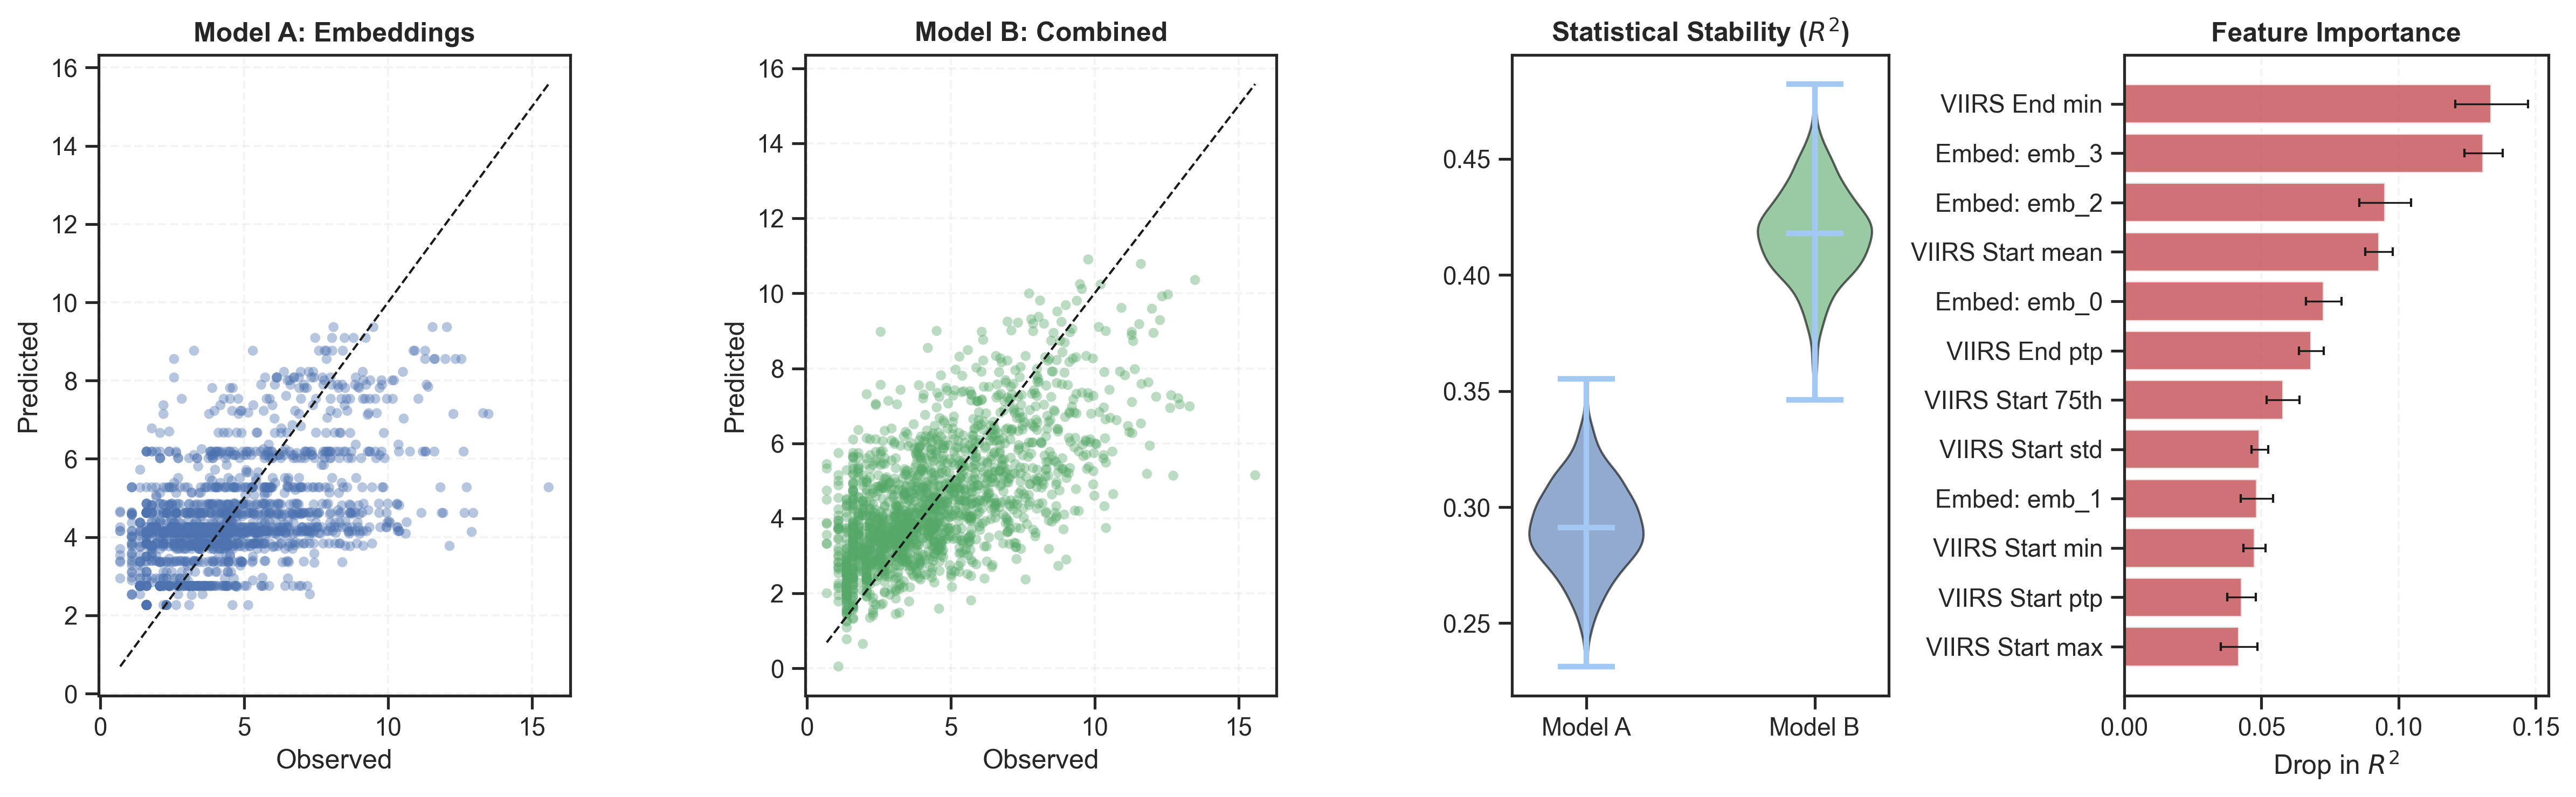

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor

# =========================================================
# CONFIG
# =========================================================
RANDOM_STATE = 42
TEST_SIZE = 0.1
BOOTSTRAP_ITERS = 1000

# =========================================================
# 1. FEATURE ENGINEERING MODULE
# =========================================================
def get_image_stats(image_array):
    """Extracts 8 statistical moments from an image array."""
    if image_array is None or len(image_array) == 0:
        return np.zeros(8)
    try:
        img = np.array(image_array)
        if img.size == 0: return np.zeros(8)
        flat = img.flatten()
        return np.array([
            np.mean(flat), np.std(flat), np.min(flat), np.max(flat),
            np.percentile(flat, 25), np.percentile(flat, 50),
            np.percentile(flat, 75), np.ptp(flat)
        ])
    except:
        return np.zeros(8)

def process_image_columns(df, columns_map):
    """Processes multiple image columns into a single feature DataFrame."""
    all_stats = []
    for col, prefix in columns_map.items():
        stats = df[col].apply(get_image_stats)
        stat_df = pd.DataFrame(np.array(stats.tolist()), 
                               columns=[f"{prefix}_{i}" for i in range(8)])
        all_stats.append(stat_df)
    return pd.concat(all_stats, axis=1)

def prepare_features(df, iso3_embeddings):
    """Merges embeddings, creates dummies, and builds image features.
       Now securely passes 'iso3' and 'type' through for later analysis."""
    embedding_df = iso3_embeddings.reset_index().rename(
        columns={iso3_embeddings.index.name or "index": "iso3"}
    )
    merged = df.merge(embedding_df, on="iso3", how="inner")
    
    type_dummies = pd.get_dummies(merged["type"], prefix="type")
    
    img_map = {"viirs_start": "vs", "viirs_end": "ve", "rgb": "rgb"}
    img_features = process_image_columns(merged, img_map)
    
    embed_cols = [c for c in embedding_df.columns if c != "iso3"]
    
    # PASS-THROUGH MODIFICATION: Keep 'iso3' and 'type' in X_full_df
    X_full_df = pd.concat([
        merged[["iso3", "type"]], 
        merged[embed_cols], 
        type_dummies, 
        img_features
    ], axis=1)
    
    y = merged["figures"].to_numpy(np.float32)
    
    return X_full_df, y, embed_cols

# =========================================================
# 2. MODELING MODULE
# =========================================================
def get_xgb_regressor():
    """Returns a pre-configured XGBoost model."""
    return XGBRegressor(
        objective="reg:squarederror",
        n_estimators=5000,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        early_stopping_rounds=100
    )

def run_bootstrap_analysis(y_true, y_pred, n_iterations=BOOTSTRAP_ITERS):
    """Calculates distribution of metrics via bootstrapping."""
    stats = {"R2": [], "MAE": [], "RMSE": []}
    rng = np.random.default_rng(RANDOM_STATE)
    for _ in range(n_iterations):
        idx = rng.choice(len(y_true), size=len(y_true), replace=True)
        y_t, y_p = y_true[idx], y_pred[idx]
        stats["R2"].append(r2_score(y_t, y_p))
        stats["MAE"].append(mean_absolute_error(y_t, y_p))
        stats["RMSE"].append(np.sqrt(mean_squared_error(y_t, y_p)))
    return pd.DataFrame(stats)

# =========================================================
# 3. VISUALIZATION MODULE
# =========================================================
def format_feature_labels(feature_names):
    """Converts internal codes to human-readable labels."""
    stat_map = {0:"mean", 1:"std", 2:"min", 3:"max", 4:"25th", 5:"50th", 6:"75th", 7:"ptp"}
    labels = []
    for f in feature_names:
        if f.startswith("type_"): labels.append(f"Type: {f[5:]}")
        elif any(f.startswith(p) for p in ["vs_","ve_","rgb_"]):
            p, i = f.split("_")
            p_map = {"vs":"VIIRS Start", "ve":"VIIRS End", "rgb":"RGB"}
            labels.append(f"{p_map[p]} {stat_map[int(i)]}")
        else: labels.append(f"Embed: {f}")
    return labels

def export_performance_pdf(y_test, pred_dict, boot_dict, imp_df, output_path="Analysis_Report.pdf"):
    """Generates the 4-panel diagnostic plot with error bars and saves to PDF."""
    plt.rcParams.update({"font.family": "Arial", "font.size": 9})
    fig = plt.figure(figsize=(16, 5), dpi=300)
    gs = GridSpec(1, 4, width_ratios=[1, 1, 0.8, 0.9])

    colors = ["#4C72B0", "#55A868"]
    
    # Panels 1 & 2: Scatters
    for i, (name, y_pred) in enumerate(pred_dict.items()):
        ax = fig.add_subplot(gs[0, i])
        ax.scatter(y_test, y_pred, s=20, alpha=0.4, color=colors[i], edgecolors='none')
        ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "--k", lw=1)
        ax.set_title(name, weight='bold')
        ax.set_xlabel("Observed")
        ax.set_ylabel("Predicted")
        ax.grid(True, linestyle="--", alpha=0.2)

    # Panel 3: R2 Stability
    ax_boot = fig.add_subplot(gs[0, 2])
    v = ax_boot.violinplot([boot_dict["A"]["R2"], boot_dict["B"]["R2"]], showmedians=True)
    for i, pc in enumerate(v['bodies']):
        pc.set_facecolor(colors[i]); pc.set_edgecolor('black'); pc.set_alpha(0.6)
    ax_boot.set_xticks([1, 2]); ax_boot.set_xticklabels(["Model A", "Model B"])
    ax_boot.set_title("Statistical Stability ($R^2$)", weight='bold')

    # Panel 4: Feature Importance with Error Bars
    ax_imp = fig.add_subplot(gs[0, 3])
    top_imp = imp_df.head(12).iloc[::-1]
    
    ax_imp.barh(top_imp["display_name"], 
                top_imp["importance_mean"], 
                xerr=top_imp["importance_std"], 
                color="#C44E52",
                alpha=0.8,
                error_kw={'capsize': 2, 'elinewidth': 0.8})
    
    ax_imp.set_title("Feature Importance", weight='bold')
    ax_imp.set_xlabel("Drop in $R^2$")
    ax_imp.grid(True, axis='x', linestyle="--", alpha=0.2)

    plt.tight_layout()
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    # plt.close()
    print(f"Report successfully saved to: {output_path}")


# =========================================================
# MAIN EXECUTION
# =========================================================
if __name__ == "__main__":
    # Ensure variables 'df' and 'iso3_embeddings' are defined in your environment
    
    # 1. Feature Engineering
    X_full, y, embed_cols = prepare_features(df, iso3_embeddings)
    y_log = np.log1p(y)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_full, y_log, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    # We dynamically drop 'iso3' and 'type' right before training Model B
    features_b = [c for c in X_full.columns if c not in ["iso3", "type"]]

    # 2. Training
    model_a = get_xgb_regressor()
    model_a.fit(X_train[embed_cols], y_train, 
                eval_set=[(X_test[embed_cols], y_test)], verbose=False)
    
    model_b = get_xgb_regressor()
    model_b.fit(X_train[features_b], y_train, 
                eval_set=[(X_test[features_b], y_test)], verbose=False)

    # 3. Evaluation & Bootstrapping
    preds_a = model_a.predict(X_test[embed_cols])
    preds_b = model_b.predict(X_test[features_b])
    
    boot_a = run_bootstrap_analysis(y_test, preds_a)
    boot_b = run_bootstrap_analysis(y_test, preds_b)

    # 4. Importance Calculation with Std Dev (using clean features_b)
    imp = permutation_importance(model_b, X_test[features_b], y_test, n_repeats=10, random_state=RANDOM_STATE)
    
    imp_df = pd.DataFrame({
        "feature": features_b,
        "importance_mean": imp.importances_mean,
        "importance_std": imp.importances_std
    }).sort_values("importance_mean", ascending=False)
    
    imp_df["display_name"] = format_feature_labels(imp_df["feature"])

    # 5. PDF Export
    export_performance_pdf(
        y_test = y_test,
        pred_dict = {"Model A: Embeddings": preds_a, "Model B: Combined": preds_b},
        boot_dict = {"A": boot_a, "B": boot_b},
        imp_df = imp_df,
        output_path = "Model_Performance_Analysis.pdf"
    )

    # =========================================================
    # POST-ANALYSIS: METRICS PER COUNTRY AND TYPE
    # =========================================================
    print("\nCalculating Post-Analysis Metrics...")
    
    results_df = pd.DataFrame({
        'iso3': X_test['iso3'],
        'type': X_test['type'],
        'y_true': y_test,
        'y_pred_A': preds_a,
        'y_pred_B': preds_b
    })

    # Function to calculate R2 safely (needs at least 2 samples)
    def safe_r2(g, pred_col):
        if len(g) > 1:
            return r2_score(g['y_true'], g[pred_col])
        return np.nan

    # Calculate R2 per Country
    r2_by_country = results_df.groupby('iso3').apply(lambda g: safe_r2(g, 'y_pred_B')).dropna().sort_values(ascending=False)
    
    # Calculate R2 per Type
    r2_by_type = results_df.groupby('type').apply(lambda g: safe_r2(g, 'y_pred_B')).dropna().sort_values(ascending=False)
    
    print("\nTop 5 Countries by R2 (Model B):")
    print(r2_by_country.head(5))
    
    print("\nR2 by Type (Model B):")
    print(r2_by_type)

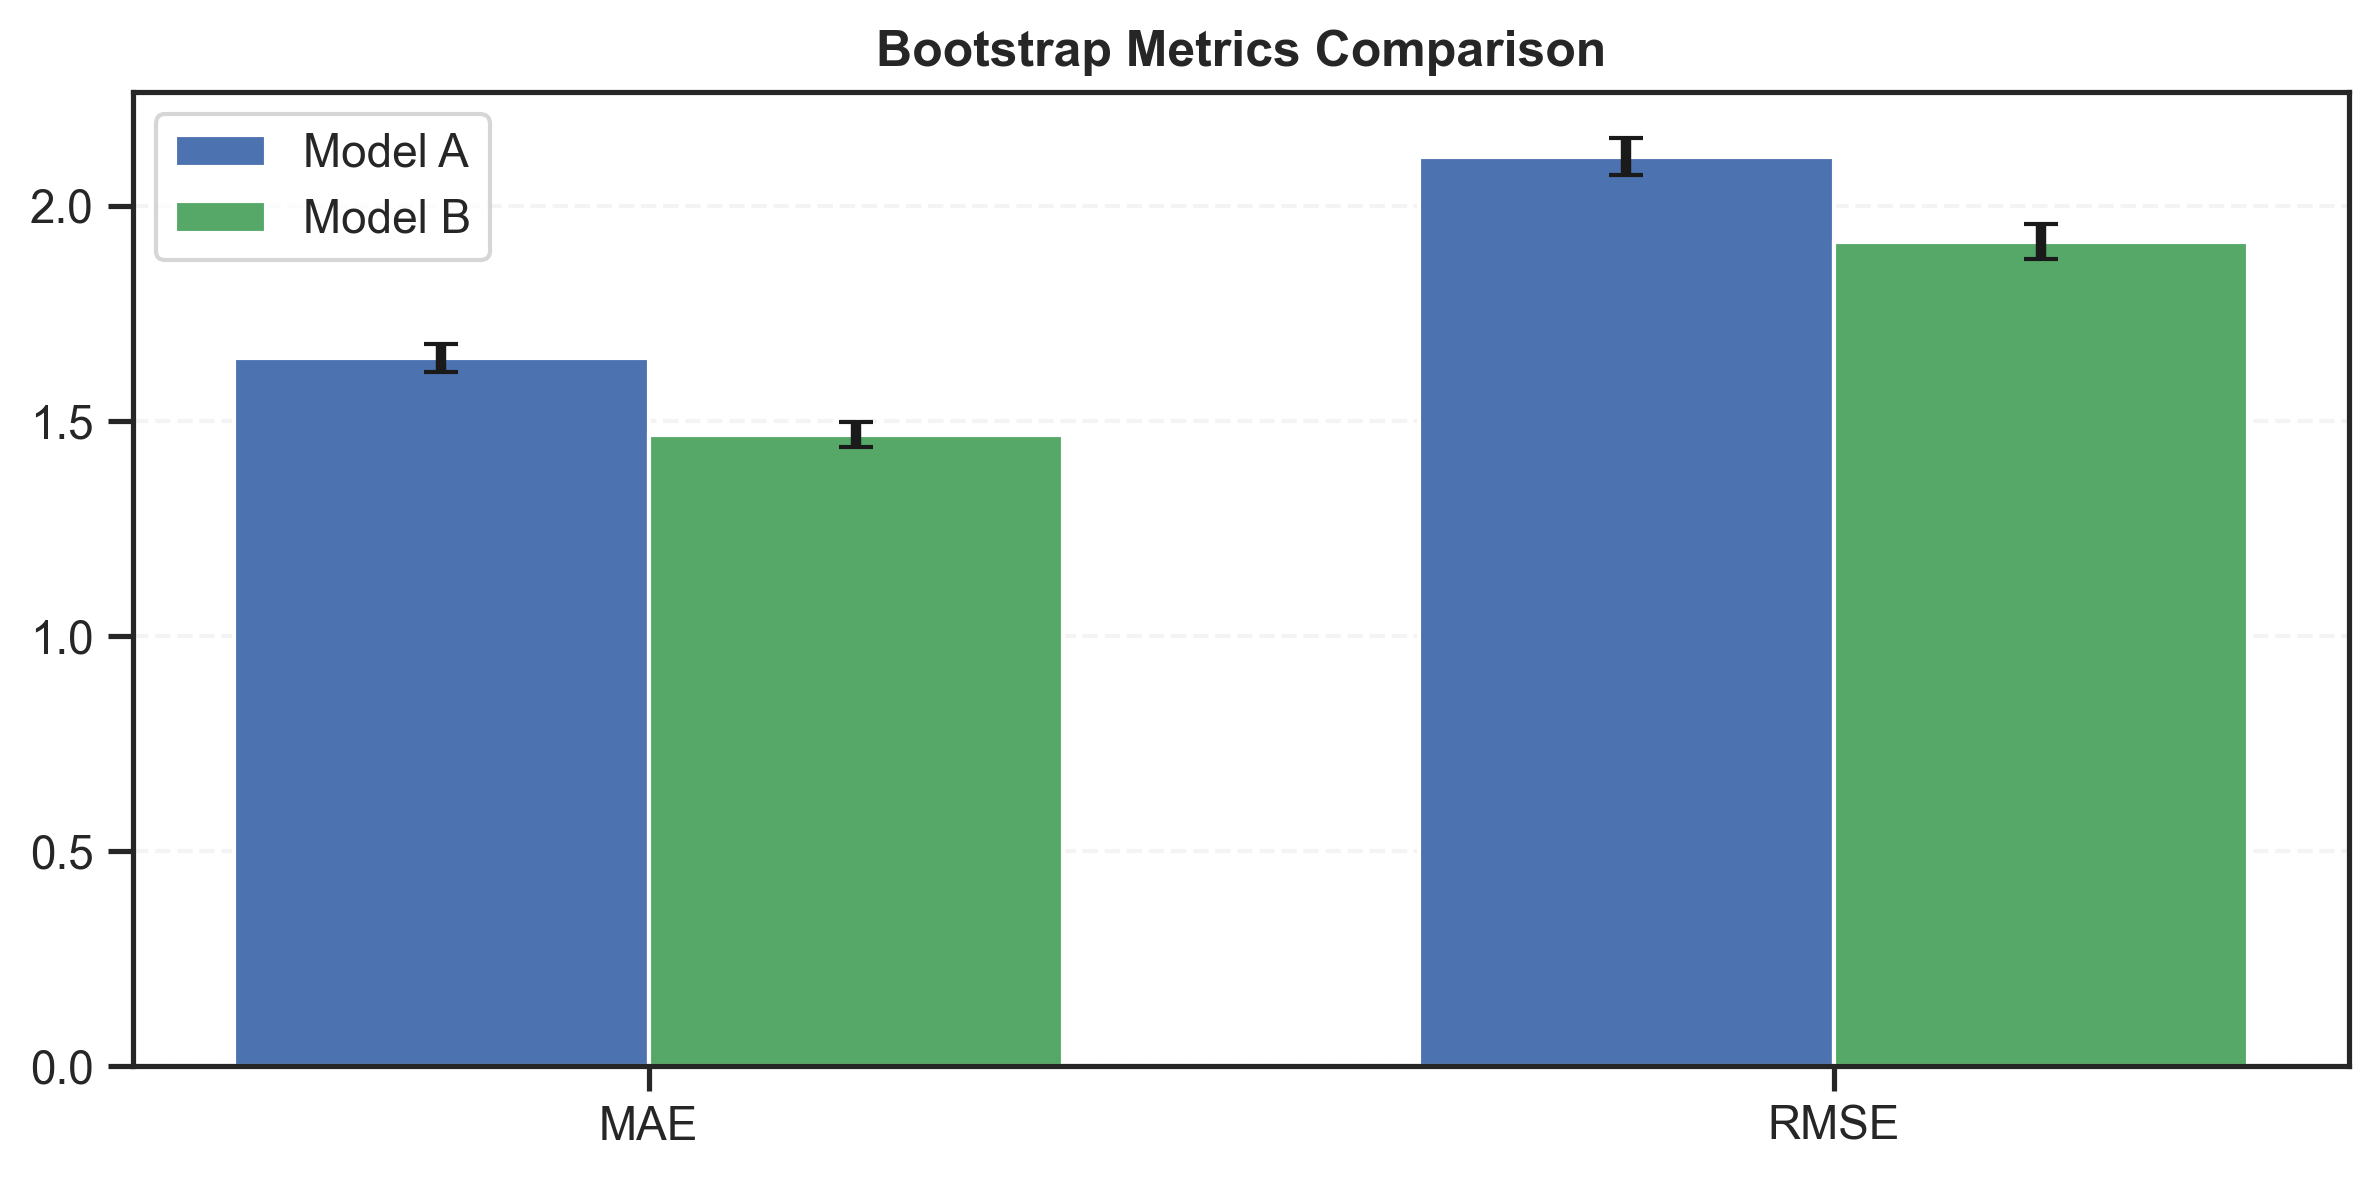

In [11]:
def plot_mae_rmse_bootstrap(boot_a, boot_b):
    """Plots bootstrap summary statistics as bar charts with error bars."""
    metrics = ["MAE", "RMSE"]
    means_a = [boot_a[m].mean() for m in metrics]
    std_a = [boot_a[m].std() for m in metrics]
    means_b = [boot_b[m].mean() for m in metrics]
    std_b = [boot_b[m].std() for m in metrics]

    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 4), dpi=300)

    ax.bar(x - width / 2, means_a, width, yerr=std_a, capsize=4, label="Model A", color="#4C72B0")
    ax.bar(x + width / 2, means_b, width, yerr=std_b, capsize=4, label="Model B", color="#55A868")

    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_title("Bootstrap Metrics Comparison", weight="bold")
    ax.grid(True, axis="y", linestyle="--", alpha=0.2)
    ax.legend()

    plt.tight_layout()
    plt.show()

plot_mae_rmse_bootstrap(boot_a, boot_b)

In [23]:
# Enhanced nature-tier visualizations for R2 performance
import plotly.graph_objects as go
import plotly.express as px

# ==================== FIGURE 1: CHOROPLETH MAP ====================
# Prepare data for choropleth
r2_country_df = r2_by_country.reset_index()
r2_country_df.columns = ["iso3", "r2"]

fig_map = px.choropleth(
    r2_country_df,
    locations="iso3",
    color="r2",
    hover_name="iso3",
    hover_data={"r2": ":.4f", "iso3": False},
    color_continuous_scale="RdYlGn",
    range_color=[-0.2, 0.8],
    labels={"r2": "R² Score"}
)

fig_map.update_geos(
    projection_type="natural earth",
    showframe=True,
    showcoastlines=True,
    coastlinecolor="RebeccaPurple",
    showland=True,
    landcolor="rgb(243, 243, 243)",
    bgcolor="rgba(240, 248, 255, 0.5)"
)

fig_map.update_layout(
    template="plotly_white",
    height=600,
    width=1200,
    margin=dict(l=10, r=10, t=80, b=10),
    font=dict(family="Arial", size=12, color="black"),
    title=dict(
        text="Global Model Performance: R² Score by Country<br><sub>Regression model predictions for climate-displaced populations</sub>",
        x=0.01,
        xanchor="left",
        font=dict(size=15, color="black", family="Arial")
    ),
    coloraxis_colorbar=dict(
        title="R² Score",
        thickness=20,
        len=0.7,
        x=1.02,
        outlinewidth=2,
        outlinecolor="black",
        tickformat=".2f",
        tickfont=dict(size=11)
    ),
)

fig_map.write_html("R2_Choropleth_Map.html")
fig_map.write_image("R2_Choropleth_Map.pdf", engine="kaleido")
fig_map.show()

# ==================== FIGURE 2: DISASTER TYPE PERFORMANCE ====================
# Prepare type data with sample counts
type_counts = results_df.groupby('type').size().reset_index(name='count')
r2_type_df = r2_by_type.reset_index()
r2_type_df.columns = ["type", "r2"]
r2_type_df = r2_type_df.merge(type_counts, on="type")

# Sort by R2 descending
r2_type_df = r2_type_df.sort_values("r2", ascending=True)

# Color based on performance
def get_color(r2):
    if r2 > 0.6:
        return "#1f77b4"  # Blue - excellent
    elif r2 > 0.4:
        return "#2ca02c"  # Green - good
    elif r2 > 0:
        return "#ff7f0e"  # Orange - moderate
    else:
        return "#d62728"  # Red - poor

colors_type = [get_color(x) for x in r2_type_df["r2"]]

fig_type = go.Figure(data=[
    go.Bar(
        y=r2_type_df["type"],
        x=r2_type_df["r2"],
        orientation='h',
        marker=dict(
            color=colors_type,
            line=dict(color="black", width=1.5)
        ),
        text=[f"R²: {r2:.3f}<br>n={count}" for r2, count in zip(r2_type_df["r2"], r2_type_df["count"])],
        textposition="outside",
        hovertemplate="<b>%{y}</b><br>R² Score: %{x:.4f}<extra></extra>",
        showlegend=False
    )
])

fig_type.update_layout(
    template="plotly_white",
    height=500,
    width=900,
    margin=dict(l=150, r=150, t=80, b=50),
    font=dict(family="Arial", size=12, color="black"),
    title=dict(
        text="Model Performance Stratified by Disaster Type<br><sub>R² Score indicates predictive accuracy for displacement estimation</sub>",
        x=0.0,
        xanchor="left",
        font=dict(size=14, color="black")
    ),
    xaxis=dict(
        title="R² Score",
        showgrid=True,
        gridwidth=1,
        gridcolor="rgba(128,128,128,0.2)",
        zeroline=True,
        zerolinewidth=2,
        zerolinecolor="black"
    ),
    yaxis=dict(
        title="Disaster Type",
        showgrid=False,
    ),
)

fig_type.write_html("R2_by_DisasterType.html")
fig_type.write_image("R2_by_DisasterType.pdf", engine="kaleido")
fig_type.show()

print("\n" + "="*70)
print("R² PERFORMANCE ANALYSIS COMPLETE")
print("="*70)
print(f"\n📊 GEOGRAPHIC INSIGHTS:")
print(f"  • Countries analyzed: {len(r2_by_country)}")
print(f"  • Countries with positive R²: {(r2_by_country > 0).sum()}")
print(f"  • Mean R² (all countries): {r2_by_country.mean():.4f}")
print(f"  • Best performing country: {r2_by_country.idxmax()} (R² = {r2_by_country.max():.4f})")

print(f"\n⚠️  DISASTER TYPE INSIGHTS:")
print(f"  • Disaster types: {len(r2_by_type)}")
print(f"  • Types with positive R²: {(r2_by_type > 0).sum()}")
print(f"  • Best type: {r2_by_type.idxmax()} (R² = {r2_by_type.max():.4f})")
print(f"  • Most challenging: {r2_by_type.idxmin()} (R² = {r2_by_type.min():.4f})")

print(f"\n📁 OUTPUTS SAVED:")
print(f"  ✓ R2_Choropleth_Map.html (interactive)")
print(f"  ✓ R2_Choropleth_Map.pdf (static)")
print(f"  ✓ R2_by_DisasterType.html (interactive)")
print(f"  ✓ R2_by_DisasterType.pdf (static)")
print("="*70)

/var/folders/ys/5gn1z90x7c1_khtjpp5kg6580000gn/T/ipykernel_31617/2089059235.py:56: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig_map.write_image("R2_Choropleth_Map.pdf", engine="kaleido")


/var/folders/ys/5gn1z90x7c1_khtjpp5kg6580000gn/T/ipykernel_31617/2089059235.py:126: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig_type.write_image("R2_by_DisasterType.pdf", engine="kaleido")



R² PERFORMANCE ANALYSIS COMPLETE

📊 GEOGRAPHIC INSIGHTS:
  • Countries analyzed: 89
  • Countries with positive R²: 45
  • Mean R² (all countries): -2.6069
  • Best performing country: AFG (R² = 0.7202)

⚠️  DISASTER TYPE INSIGHTS:
  • Disaster types: 10
  • Types with positive R²: 8
  • Best type: Mixed disasters (R² = 0.7941)
  • Most challenging: Extreme Temperature (R² = -3.2968)

📁 OUTPUTS SAVED:
  ✓ R2_Choropleth_Map.html (interactive)
  ✓ R2_Choropleth_Map.pdf (static)
  ✓ R2_by_DisasterType.html (interactive)
  ✓ R2_by_DisasterType.pdf (static)
